# Architecture of filters

So, the english is not very good, I will improve that

In [388]:
import itertools

import sympy as sy
import numpy as np

from sympy import Matrix
from scipy.linalg import circulant
from sympy.physics.quantum import TensorProduct
from sympy.matrices.dense import matrix_multiply_elementwise

In [389]:
import fitz

from utils import plot_pdf, plot_pdf2col, symmetrical_cyclic_convolution, conv_circ_fft

In [390]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [391]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This tutorial not work with others vector sizes

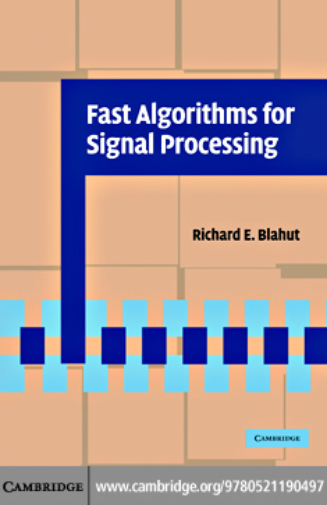

In [392]:
plot_pdf(doc[0], dpi=100)

## Polynomials

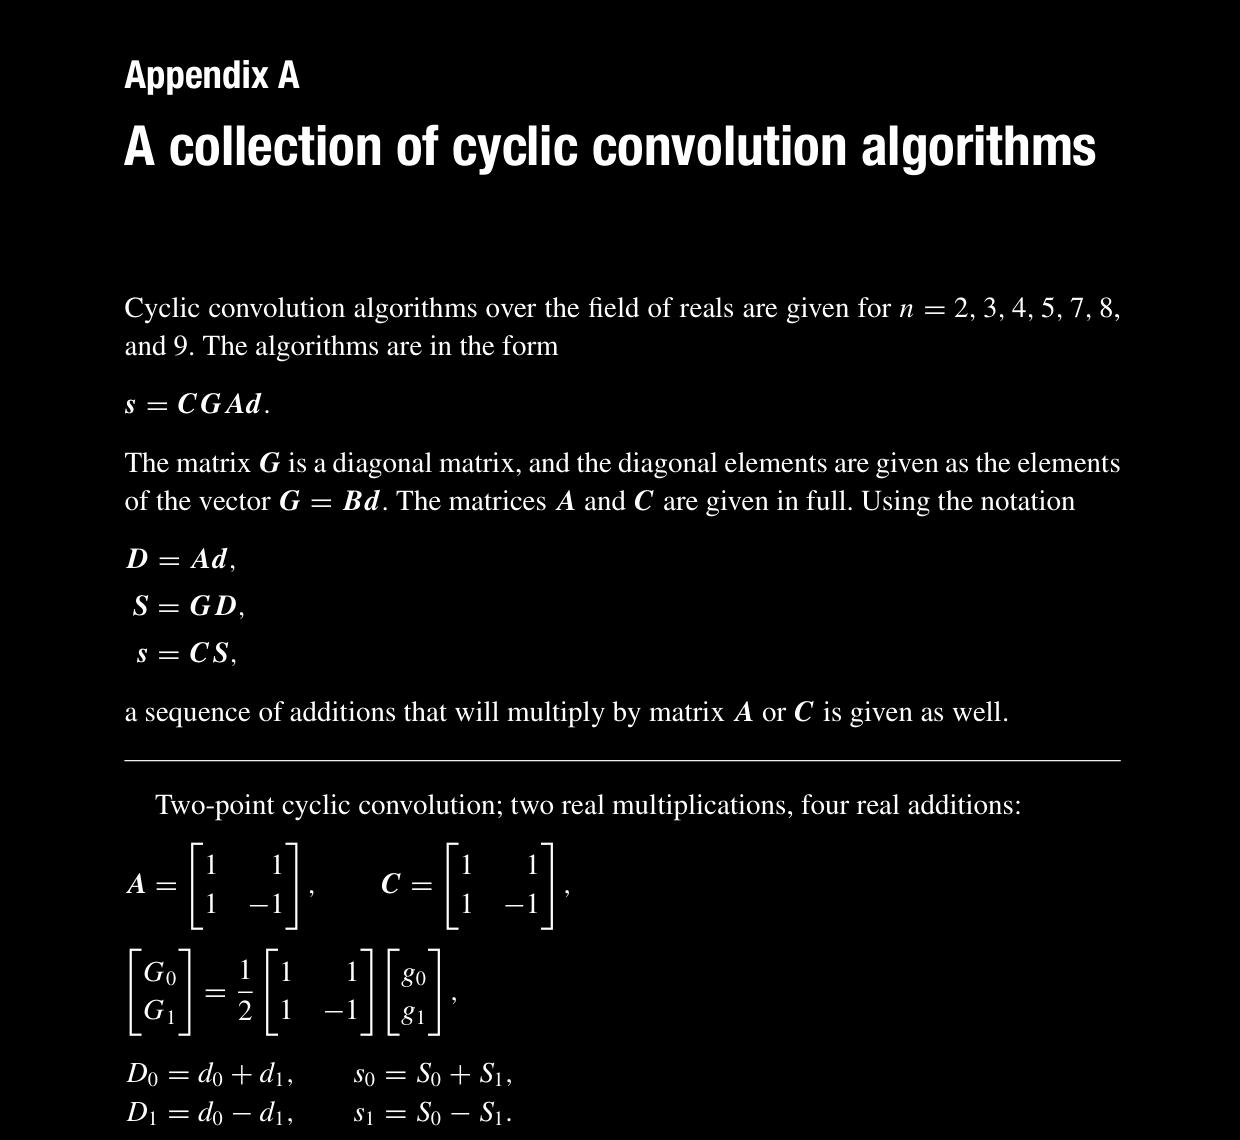

In [393]:
plot_pdf(doc[442], [0.1, .7])

Size of vectors

In [394]:
v_size = 2

Example of vectors for the convolution

In [395]:
d_values = list(range(1, v_size+1))
g_values = list(range(1, v_size+1))
print(d_values, g_values)

[1, 2] [1, 2]


Polynomial degree

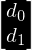

In [396]:
d0s = Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(v_size))))
d0s

In [397]:
g0s = Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(v_size))))
g0s

In [398]:
t0s = Matrix(sy.symbols(" ".join(f"t_{i}"for i in range(v_size))))
t0s

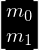

In [399]:
m0s = Matrix(sy.symbols(" ".join(f"m_{i}"for i in range(v_size))))
m0s

In [400]:
s0s = Matrix(sy.symbols(" ".join(f"s_{i}"for i in range(v_size))))
s0s

Just defining values of matrices (acho que não foi winograd que definiu a matriz abaixo, acho q foi agarwal e burrus)

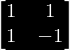

In [401]:
win = Matrix([[1, 1], [1, -1]])
win

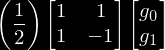

In [402]:
sy.MatMul(sy.Rational(1, 2), win, g0)

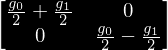

In [403]:
bg0s = sy.diag(*(win*g0*1/2).tolist())
bg0s

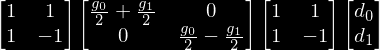

In [404]:
sy.MatMul(win, bg0s, win, d0)

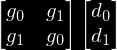

In [405]:
sy.MatMul(win * bg0s * win, d0)

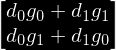

In [406]:
sy.MatMul(win, bg0s, win, d0, evaluate=True)

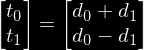

In [407]:
t0 = sy.Eq(t0s, win * d0)
t0

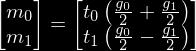

In [408]:
m0 = sy.Eq(m0s, bg0s*t0.args[0])
m0

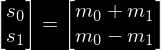

In [409]:
s0 = sy.Eq(s0s, win*m0.args[0])
s0